<a href="https://colab.research.google.com/github/ChenS1313/thelook-ecommerce-analytics-pipeline/blob/ChenS1313-patch-4/thelooker_ecommerce_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1 Data Loading & Initial Exploration


### 1.1 Loading the relevant tables from **Google BigQuery**

In [24]:
# Import relevant libraries
from google.colab import auth
from google.cloud import bigquery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Connect Google account for BigQuery access
auth.authenticate_user()

In [26]:
# Set up the BigQuery connection and dataset name
client = bigquery.Client(project="project-69dc4deb-819d-43d1-af9")
dataset = "dbt_csinai"

# Create dataframe for each table
df_users = client.list_rows(f"{dataset}.dim_users").to_dataframe()
df_orders = client.list_rows(f"{dataset}.dim_orders").to_dataframe()
df_products = client.list_rows(f"{dataset}.dim_products").to_dataframe()
df_order_items = client.list_rows(f"{dataset}.fct_order_items").to_dataframe()


### 1.2 Checking the data structure to make sure everything loaded correctly

In [27]:
# Verify table sizes and row counts
print(f"Users table:{df_users.shape}")
print(f"Orders table:{df_orders.shape}")
print(f"Products table:{df_products.shape}")
print(f"Order_items table:{df_order_items.shape}")

Users table:(100000, 21)
Orders table:(125162, 16)
Products table:(29120, 17)
Order_items table:(181397, 21)


In [28]:
# Check column names and data types using .info()
datasets = {
    "Users": df_users,
    "Orders": df_orders,
    "Products": df_products,
    "Order Items": df_order_items
}

for name,df in datasets.items():
   print(f"======== {name} Table Info ========")
   df.info()
   print("\n")

======== Users Table Info ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   user_id                 100000 non-null  object             
 1   first_name              100000 non-null  object             
 2   last_name               100000 non-null  object             
 3   age                     100000 non-null  Int64              
 4   user_age_group          79931 non-null   object             
 5   gender                  100000 non-null  object             
 6   email                   100000 non-null  object             
 7   address                 100000 non-null  object             
 8   city                    100000 non-null  object             
 9   state                   100000 non-null  object             
 10  country                 100000 non-null  object           

In [29]:
# Inspect the data samples
df_users.head()
df_products.head()
df_order_items.head()
df_orders.head()

,order_id,user_id,status,gender,num_of_items,customer_country,created_at,shipped_at,delivered_at,returned_at,order_sales,order_cost,order_profit,returned_items_count,days_to_ship,days_to_deliver
0,704,558,Cancelled,F,2,United States,2025-07-31 16:33:51+00:00,NaT,NaT,NaT,79.890000000,43.740000000,36.150000000,0,<NA>,<NA>
1,885,704,Cancelled,F,2,Brasil,2023-07-15 17:36:03+00:00,NaT,NaT,NaT,231.990000000,101.470000000,130.520000000,0,<NA>,<NA>
2,2254,1800,Cancelled,F,2,Belgium,2022-02-12 00:09:40+00:00,NaT,NaT,NaT,110.000000000,54.600000000,55.400000000,0,<NA>,<NA>
3,2324,1854,Cancelled,F,1,Brasil,2024-02-17 02:45:04+00:00,NaT,NaT,NaT,9.490000000,5.090000000,4.400000000,0,<NA>,<NA>
4,2666,2122,Cancelled,F,1,Brasil,2026-01-14 03:30:56+00:00,NaT,NaT,NaT,11.130000000,6.010000000,5.120000000,0,<NA>,<NA>


## 2 Data Formatting

Due to default Pandas display settings when loading data from **Google BigQuery**, we apply light formatting to improve readability without changing the actual data:

- **Dates:** Standardize date formatting.

- **Numeric Columns:** Round prices and costs to 2 decimal places.
This includes casting numeric columns back to `float64` if BigQuery's `NUMERIC` type forced them into Python `object` types during import.

- **Missing Data:** Keep empty cells as Pandas `NaT` / `NaN` / `<NA>` (which match BigQuery `NULL`s).



In [30]:
# Format all date columns across all tables
dfs_list = [df_users, df_products, df_order_items, df_orders]
for df in dfs_list:
    for col in df.columns:
        # Check if the column is of datetime type
        if df[col].dtype == 'datetime64[us, UTC]':
                df[col] = pd.to_datetime(df[col]).dt.tz_localize(None).astype('datetime64[s]')

In [31]:
# Convert BigQuery NUMERIC columns from object back to float

# df_users
df_users['lifetime_value'] = pd.to_numeric(df_users['lifetime_value'], errors = 'coerce')
df_users['total_profit'] = pd.to_numeric(df_users['total_profit'], errors = 'coerce')

# df_products
df_products['sale_price'] = pd.to_numeric(df_products['sale_price'], errors = 'coerce')
df_products['cost'] = pd.to_numeric(df_products['cost'], errors = 'coerce')
df_products['total_sales'] = pd.to_numeric(df_products['total_sales'], errors = 'coerce')
df_products['total_profit'] = pd.to_numeric(df_products['total_profit'], errors = 'coerce')


# df_order_items
df_order_items['sale_price'] = pd.to_numeric(df_order_items['sale_price'], errors = 'coerce')
df_order_items['cost'] = pd.to_numeric(df_order_items['cost'], errors = 'coerce')
df_order_items['profit'] = pd.to_numeric(df_order_items['profit'], errors = 'coerce')

# df_orders
df_orders['order_sales'] = pd.to_numeric(df_orders['order_sales'], errors = 'coerce')
df_orders['order_cost'] = pd.to_numeric(df_orders['order_cost'], errors = 'coerce')
df_orders['order_profit'] = pd.to_numeric(df_orders['order_profit'], errors = 'coerce')


In [32]:
# Check that all data types were successfully updated across all datasets using .info()
for name,df in datasets.items():
   print(f"======== {name} Table Info ========")
   df.info()
   print("\n")

======== Users Table Info ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype        
---  ------                  --------------   -----        
 0   user_id                 100000 non-null  object       
 1   first_name              100000 non-null  object       
 2   last_name               100000 non-null  object       
 3   age                     100000 non-null  Int64        
 4   user_age_group          79931 non-null   object       
 5   gender                  100000 non-null  object       
 6   email                   100000 non-null  object       
 7   address                 100000 non-null  object       
 8   city                    100000 non-null  object       
 9   state                   100000 non-null  object       
 10  country                 100000 non-null  object       
 11  postal_code             100000 non-null  object       
 12  latitude  

## 3 Deep EDA & Vizualizations

### 3.1 Data Overview & Insights

In [33]:
df_users.describe().T

,count,mean,min,25%,50%,75%,max,std
age,100000.0,40.93952,12.0,26.0,41.0,56.0,70.0,17.048016
latitude,100000.0,28.345561,-43.253132,26.198622,35.248808,40.702294,64.865194,22.030017
longitude,100000.0,24.672358,-158.164931,-51.104159,4.51684,116.391848,153.559993,90.115683
total_orders,100000.0,1.25162,0.0,1.0,1.0,2.0,4.0,0.996864
lifetime_value,100000.0,108.286869,0.0,16.0,62.0,151.6,1902.59,136.376211
total_profit,100000.0,56.196505,0.0,8.25,31.23,77.88,1037.56,72.691288
first_order_date,79931,2024-06-11 14:03:14,2019-01-11 04:00:50,2023-04-04 02:19:50,2024-11-17 15:33:46,2025-12-17 03:19:42,2026-07-30 00:41:19,NaN
most_recent_order_date,79931,2025-01-04 19:36:32,2019-01-18 15:18:18,2024-03-17 08:51:04,2025-07-11 13:15:10,2026-03-29 11:20:32,2026-07-30 00:41:19,NaN
user_created_at,100000,2022-11-20 03:45:10,2019-01-02 00:16:00,2020-12-11 12:37:00,2022-11-18 05:32:00,2024-10-28 05:29:45,2026-07-29 19:23:43,NaN


#### 🔍 Insights: `df_users`
* **Age Demographics (`age`):** The average and median age are both **41 years old**, showing a balanced, normal distribution.

* **Customer Retention (`total_orders`):** Over **50% of users have placed only 1 order**. Since this data covers 2019 to 2026, it shows a real **retention challenge** - most customers remain one-time buyers.

* **User Activation (`first_order_date`):** Out of 100,000 registered users, only **79,931 have placed an order**. This leaves ~20,000 "dormant" accounts (non-buyers) that registered but never made a purchase.

* **Lifetime Value (`lifetime_value`):** LTV is **right-skewed**. Most users spend around **\$62.00** (median), but a small group of big spenders pulls the average up to **$108.28**.



In [34]:
df_products.describe().T

,count,mean,std,min,25%,50%,75%,max
sale_price,29120.0,59.220164,65.888927,0.02,24.0,39.99,69.95,999.0
cost,29120.0,28.481889,30.624695,0.01,11.28,19.68,34.44,557.15
total_units_sold,29120.0,6.229293,2.569665,0.0,4.0,6.0,8.0,18.0
total_sales,29120.0,371.864247,479.228573,0.0,120.0,234.0,444.0,11400.0
total_profit,29120.0,192.982502,263.129843,0.0,60.06,116.82,224.5525,6817.2
total_units_returned,29120.0,0.617995,0.784491,0.0,0.0,0.0,1.0,6.0
distribution_center_longitude,29120.0,-88.541508,11.672085,-118.25,-90.0667,-88.0431,-79.9333,-73.7834
distribution_center_latitude,29120.0,34.942039,4.431663,29.7604,30.6944,34.05,39.95,41.8369


#### 🔍 Insights: `df_products`
* **Pricing Strategy (`sale_price` vs. `cost`):** The average sale price ($59.22) is more than **double the average cost** (\$28.48), demonstrating a healthy pricing model.

* **Inventory (`total_units_sold`):**  Some products have **0 units sold**, indicating new catalog additions or inactive "deadstock" products.

* **Product Price Distribution (`sale_price`):**  The price distribution is **right-skewed** (ranging from \$0.02 up to \$999.00). Since 75% of items under $69.95, the store mostly focuses on everyday affordable items, with a few high-end luxury products on top.

In [35]:
df_orders.describe().T

,count,mean,min,25%,50%,75%,max,std
num_of_items,125162.0,1.449298,1.0,1.0,1.0,2.0,4.0,0.805612
created_at,125162,2024-09-22 16:23:47,2019-01-11 04:00:50,2023-09-23 15:58:07,2025-03-18 12:09:39,2026-02-11 06:41:28,2026-07-30 00:41:19,NaN
shipped_at,81303,2024-09-22 19:58:55,2019-01-11 12:14:50,2023-09-23 02:40:31,2025-03-19 10:52:50,2026-02-12 18:24:25,2026-08-01 23:46:43,NaN
delivered_at,43737,2024-09-26 01:41:24,2019-02-02 14:38:48,2023-09-27 16:39:02,2025-03-22 22:42:56,2026-02-15 17:02:04,2026-08-06 10:51:51,NaN
returned_at,12483,2024-09-20 15:04:02,2019-02-04 17:39:48,2023-09-03 11:51:41,2025-03-18 12:06:06,2026-02-11 23:02:34,2026-08-08 18:22:18,NaN
order_sales,125162.0,86.517369,0.02,29.5,55.57,110.0,1892.25,93.497365
order_cost,125162.0,41.618354,0.01,14.28,27.59,53.25,976.49,43.850512
order_profit,125162.0,44.899015,0.01,14.71,28.01,56.76,915.76,50.712226
returned_items_count,125162.0,0.143782,0.0,0.0,0.0,0.0,4.0,0.500337
days_to_ship,81303.0,0.99465,0.0,0.0,1.0,2.0,2.0,0.815089


#### 🔍 Insights: `df_orders`
* **Basket Size (`num_of_items`):** The majority of orders contain only **1 item** (Median: 1, 75th percentile: 2).
* **Returns (`returned_at` & `returned_items_count`):**  While the vast majority of orders have zero returns (`returned_items_count` 75th percentile	= 0), overall **~10% of total orders** (12,483 orders) end up being returned.
* **Order Value (`order_sales`):** The Average Order Value (AOV) stands at \$86, but the distribution is right-skewed with high-value outliers reaching up to **$1,892.25**.

* **Shipping (`days_to_ship`):**  Most orders are shipped within **1 day**, with a maximum of **2 days**.
* **Delivery (`days_to_deliver`):** Final delivery to customers takes **~3 days on average** (Median: 3.0 days) with a maximum delivery time of **7 days**

In [36]:
df_order_items.describe().T

,count,mean,min,25%,50%,75%,max,std
order_created_at,181397,2024-09-23 07:53:56,2019-01-11 04:00:50,2023-09-24 08:45:34,2025-03-19 02:11:20,2026-02-11 17:45:59,2026-07-30 00:41:19,NaN
item_created_at,181397,2024-09-24 06:52:04,2019-01-11 01:22:24,2023-09-25 05:21:04,2025-03-20 00:09:35,2026-02-12 16:31:05,2026-08-02 23:54:58,NaN
shipped_at,117663,2024-09-24 01:20:29,2019-01-11 12:14:50,2023-09-25 23:03:03,2025-03-21 03:30:52,2026-02-13 16:00:32,2026-08-01 23:46:43,NaN
delivered_at,63360,2024-09-28 12:26:33,2019-02-02 14:38:48,2023-10-01 11:18:08,2025-03-26 16:46:27,2026-02-17 19:48:30,2026-08-06 10:51:51,NaN
returned_at,17996,2024-09-23 12:54:24,2019-02-04 17:39:48,2023-09-11 15:56:49,2025-03-19 03:07:27,2026-02-11 23:40:24,2026-08-08 18:22:18,NaN
customer_age,181397.0,40.959255,12.0,26.0,41.0,56.0,70.0,17.049871
sale_price,181397.0,59.696064,0.02,24.5,39.99,69.95,999.0,66.374413
cost,181397.0,28.716221,0.01,11.38,19.84,34.55,557.15,30.812198
profit,181397.0,30.979842,0.01,11.72,20.24,35.9,594.4,36.580634


#### 🔍 Insights: `df_order_items`

* **Item Profitability (`profit`):** Profitability per item is strong at **~52% margin** (calculated as (`profit` / `sale_price`) * 100). Most items make around **\$20.24** (median), but a few high-priced premium products push the overall average up to **\$30.98**, creating a right-skewed distribution.

### 3.2 Vizualizations & Sub-Business Questions
 **Main Business Question:**
> "How can we grow company revenue and profits by focusing on the right countries and personalizing products for different customer groups?"

#### 📊 1 Market Opportunity Identification
*Which markets present high Average Order Value (AOV) despite low current order volume?*

In [37]:
# Create country-level aggregation
country_analysis = (df_orders.groupby("customer_country").agg(AOV=("order_sales", "mean"),
                                                              order_count=("order_id", "count")).sort_values(by="AOV", ascending=False))

country_analysis = country_analysis[country_analysis["order_count"] > 1000] # Filter outliers (countries with less than 1000 orders) to prevent bias

country_analysis.reset_index(inplace=True) # Reset index

country_analysis


,customer_country,AOV,order_count
0,Belgium,90.648391,1492
1,Australia,88.599971,2774
2,Germany,87.500049,5317
3,Brasil,87.488037,18160
4,Japan,86.794242,3126
5,United Kingdom,86.647857,5777
6,China,86.343161,42111
7,United States,86.231911,28555
8,Spain,85.772043,4870
9,South Korea,85.509591,6772


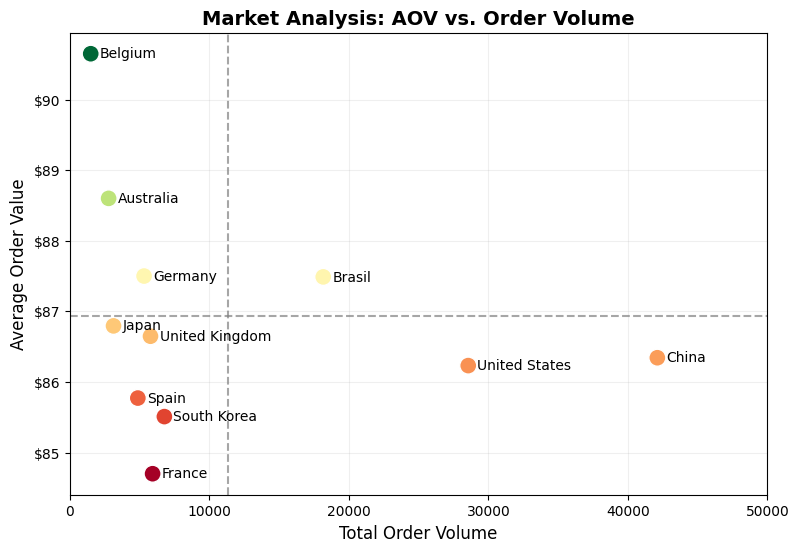

In [38]:
# Scatter plot

plt.figure(figsize=(9, 6))
sns.scatterplot(data=country_analysis, x='order_count', y="AOV",
                        s=150,
                        hue="AOV",
                        palette="RdYlGn",
                        legend=False
                        )

# Reference lines for averages
plt.axhline(country_analysis["AOV"].mean(), color="gray", linestyle="--", alpha=0.7) # AOV average
plt.axvline(country_analysis['order_count'].mean(), color="gray", linestyle="--", alpha=0.7) # Orders average

# Add country names
for idx, row in country_analysis.iterrows():
    plt.text(
        row["order_count"] + 650, # X
        row["AOV"], # Y
        row["customer_country"], # Name
        fontsize=10,
        va="center"
        )

plt.xlim(0,50000)
plt.xlabel("Total Order Volume", fontsize=12)
plt.ylabel("Average Order Value", fontsize=12)
plt.grid(True, alpha=0.2)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')

plt.title("Market Analysis: AOV vs. Order Volume", fontsize=14, fontweight="bold")
plt.show()

#### 💡 Business Insights & Strategy

* **Retention (US, China, Brazil):** Most orders come from these countries, so it is important to focus on keeping these customers.
* **Growth (Belgium & Australia):** These countries have the highest AOV, but low order volume. We should invest in marketing campaigns there in order to scale volume.


* 🎯 Recommended Strategic Actions
  * **Core Markets (US, China, Brazil):** Run targeted loyalty rewards and win-back offers to keep existing buyers coming back.

  *  **High-AOV Markets (Belgium & Australia):** Run ads aimed at new shoppers to grow order volume while keeping AOV high.


#### 📊 2 Product-Demographic Fit Analysis
*Which product categories are bought the most across different age groups and genders?*

In [39]:
# Create separated df for male and female
male_items = df_order_items[df_order_items["customer_gender"] == "M"]
female_items = df_order_items[df_order_items["customer_gender"] == "F"]

In [40]:
# Create aggregated category-age-group sales for male and female
male_age_group_sales = male_items.groupby(["customer_age_group","category"])["sale_price"].sum().reset_index()
male_age_group_sales["total_males_age_group_sales"] = male_age_group_sales.groupby("customer_age_group")["sale_price"].transform("sum")
male_age_group_sales["perc_from_total"] = (male_age_group_sales["sale_price"] / male_age_group_sales["total_males_age_group_sales"]) * 100

female_age_group_sales = female_items.groupby(["customer_age_group","category"])["sale_price"].sum().reset_index()
female_age_group_sales["total_female_age_group_sales"] = female_age_group_sales.groupby("customer_age_group")["sale_price"].transform("sum")
female_age_group_sales["perc_from_total"] = (female_age_group_sales["sale_price"] / female_age_group_sales["total_female_age_group_sales"]) * 100

In [41]:
# Create heatmap df for each gender
male_heatmap = male_age_group_sales.pivot(index="customer_age_group", columns="category", values="perc_from_total")
female_heatmap = female_age_group_sales.pivot(index="customer_age_group", columns="category", values="perc_from_total")


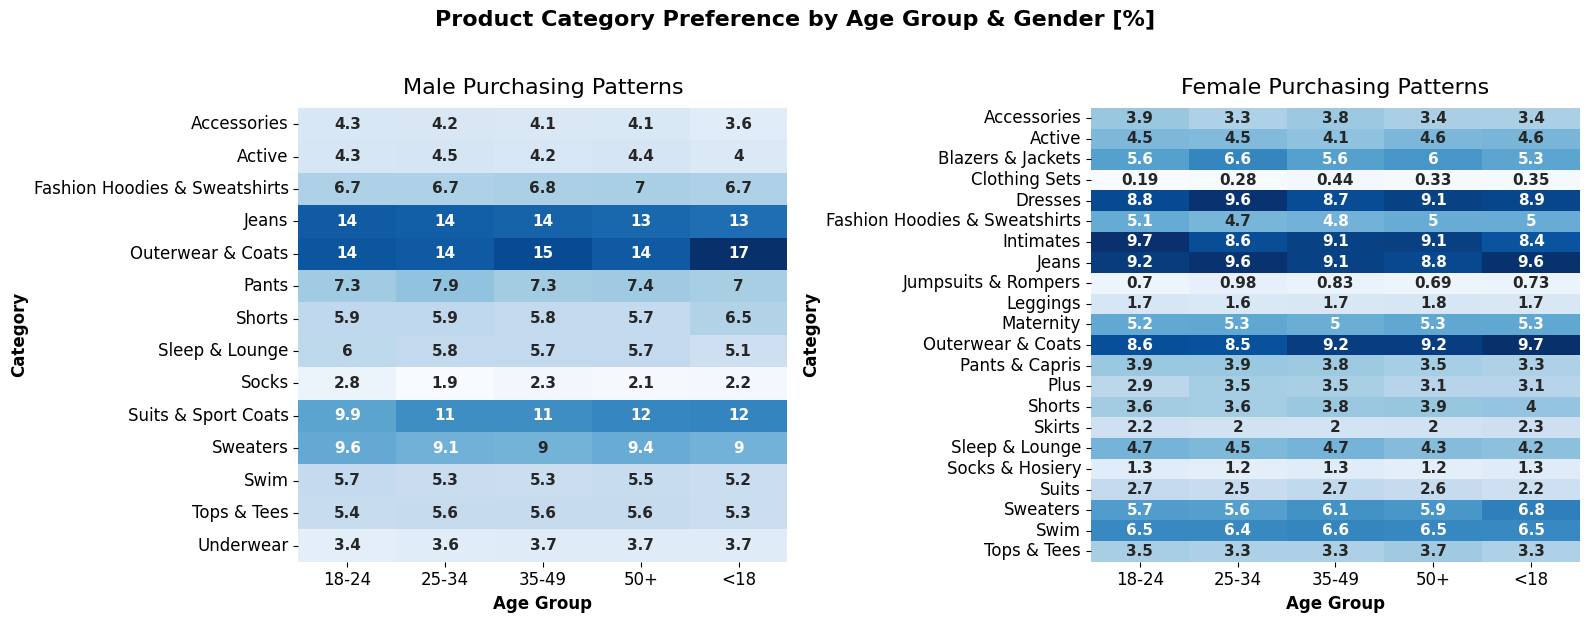

In [42]:
# Create heatmaps

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

heatmaps_list = [male_heatmap, female_heatmap]
titles = ["Male Purchasing Patterns", "Female Purchasing Patterns"]

for i in range(len(heatmaps_list)):
    ax = axes[i]
    sns.heatmap(heatmaps_list[i].T, ax=ax,
                cmap="Blues",
                annot=True, # Shows numbers
                annot_kws={"size": 11, "weight": "bold"}, # Format numbers
                cbar=False
               )

    # Titles and Labels
    ax.set_xlabel("Age Group", fontsize=12, fontweight="bold")
    ax.set_ylabel("Category", fontsize=12, fontweight="bold")
    ax.set_title(titles[i], fontsize=16, pad=10)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

# Fig title
fig.suptitle("Product Category Preference by Age Group & Gender [%]", fontsize=16, fontweight="bold", y=1.03)

plt.tight_layout()
plt.show()

#### 💡 Business Insights & Strategy

* **Top sellers:** *Outerwear & Coats* and *Jeans* are the top sellers categories across almost all age groups. Keeping high stock and promoting them in ad campaigns is critical.

* **Youth (<18)**: *Outerwear & Coats* demand peaks in the under-18 group. Launching seasonal, targeted ad campaigns for this segment is key to capturing youth market share.

* **Targeted Gender Campaigns (Suits vs. Variety):** Men focus heavily on high-ticket items like Suits and Sweaters, while women buy across a broader range of categories like Dresses and Intimates. Ad campaigns should target these distinct buying habits.

* 🎯 Recommended Strategic Actions

  * **Personalized Ads:** Create ad campaigns based on gender—highlight *Outerwear & Suits* for male users, and feature *Dresses & Intimates* for female users.